## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

In [2]:
# Load the dataset
movie_df = pd.read_csv('imdb_top_1000.csv')

# Display the first few rows of the dataset
movie_df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## 3. Data Overview

In [3]:
# shape of the dataset
print('Shape of the dataset:', movie_df.shape)

# info about the dataset
print('\nInfo about the dataset:')
print(movie_df.info())

Shape of the dataset: (1000, 16)

Info about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
mem

In [4]:
# Describe the Categorical columns
movie_df.describe(include='object').T

,count,unique,top,freq
Poster_Link,1000,1000,https://m.media-amazon.com/images/M/MV5BMDFkYT...,1
Series_Title,1000,999,Drishyam,2
Released_Year,1000,100,2014,32
Certificate,899,16,U,234
Runtime,1000,140,100 min,23
Genre,1000,202,Drama,85
Overview,1000,1000,Two imprisoned men bond over a number of years...,1
Director,1000,548,Alfred Hitchcock,14
Star1,1000,660,Tom Hanks,12
Star2,1000,841,Emma Watson,7


In [5]:
# Describe the numerical columns
movie_df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
IMDB_Rating,1000.0,7.94930,0.275491,7.6,7.70,7.9,8.10,9.3
Meta_score,843.0,77.97153,12.376099,28.0,70.00,79.0,87.00,100.0
No_of_Votes,1000.0,273692.91100,327372.703934,25088.0,55526.25,138548.5,374161.25,2343110.0


In [6]:
# Check for missing values
print('Missing values in each column:')
print(movie_df.isnull().sum())

# Check for duplicate entries
print('\nNumber of duplicate entries:')
print(movie_df.duplicated().sum())


Missing values in each column:
Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

Number of duplicate entries:
0


## 4. Cleaning Data

In [7]:
# Copy dataset
movie_cleaned = movie_df.copy()

# Extract year from 'Released_Year'
movie_cleaned['Released_Year'] = pd.to_numeric(movie_cleaned['Released_Year'], errors='coerce')
movie_cleaned.dropna(subset=['Released_Year'], inplace=True)

# Convert 'Runtime' to numeric (in minutes)
movie_cleaned['Runtime'] = movie_cleaned['Runtime'].str.replace(' min', '').astype(int)

# Remove commas from 'Gross' and convert to numeric
movie_cleaned['Gross'] = movie_cleaned['Gross'].str.replace(',', '')
movie_cleaned['Gross'] = pd.to_numeric(movie_cleaned['Gross'], errors='coerce')

# Handle missing values
movie_cleaned.fillna({
    'Meta_score': movie_cleaned['Meta_score'].median(),
    'Gross': movie_cleaned['Gross'].median(),
    'Certificate': 'Unknown'
}, inplace=True)


# Drop unsended columns
movie_cleaned.drop(columns=[
    'Poster_Link', 
    'Series_Title',
    'Star1', 'Star2', 'Star3', 'Star4'], axis=1, inplace=True)

# Check the cleaned dataset
print('Shape of the cleaned dataset:', movie_cleaned.shape)
print('\nInfo about the cleaned dataset:')
print(movie_cleaned.info()) 

Shape of the cleaned dataset: (999, 10)

Info about the cleaned dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Released_Year  999 non-null    float64
 1   Certificate    999 non-null    object 
 2   Runtime        999 non-null    int64  
 3   Genre          999 non-null    object 
 4   IMDB_Rating    999 non-null    float64
 5   Overview       999 non-null    object 
 6   Meta_score     999 non-null    float64
 7   Director       999 non-null    object 
 8   No_of_Votes    999 non-null    int64  
 9   Gross          999 non-null    float64
dtypes: float64(4), int64(2), object(4)
memory usage: 85.9+ KB
None


In [8]:
# Check for missing values after cleaning
print('Missing values in each column after cleaning:')
print(movie_cleaned.isnull().sum())

Missing values in each column after cleaning:
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Overview         0
Meta_score       0
Director         0
No_of_Votes      0
Gross            0
dtype: int64


## 6. EDA

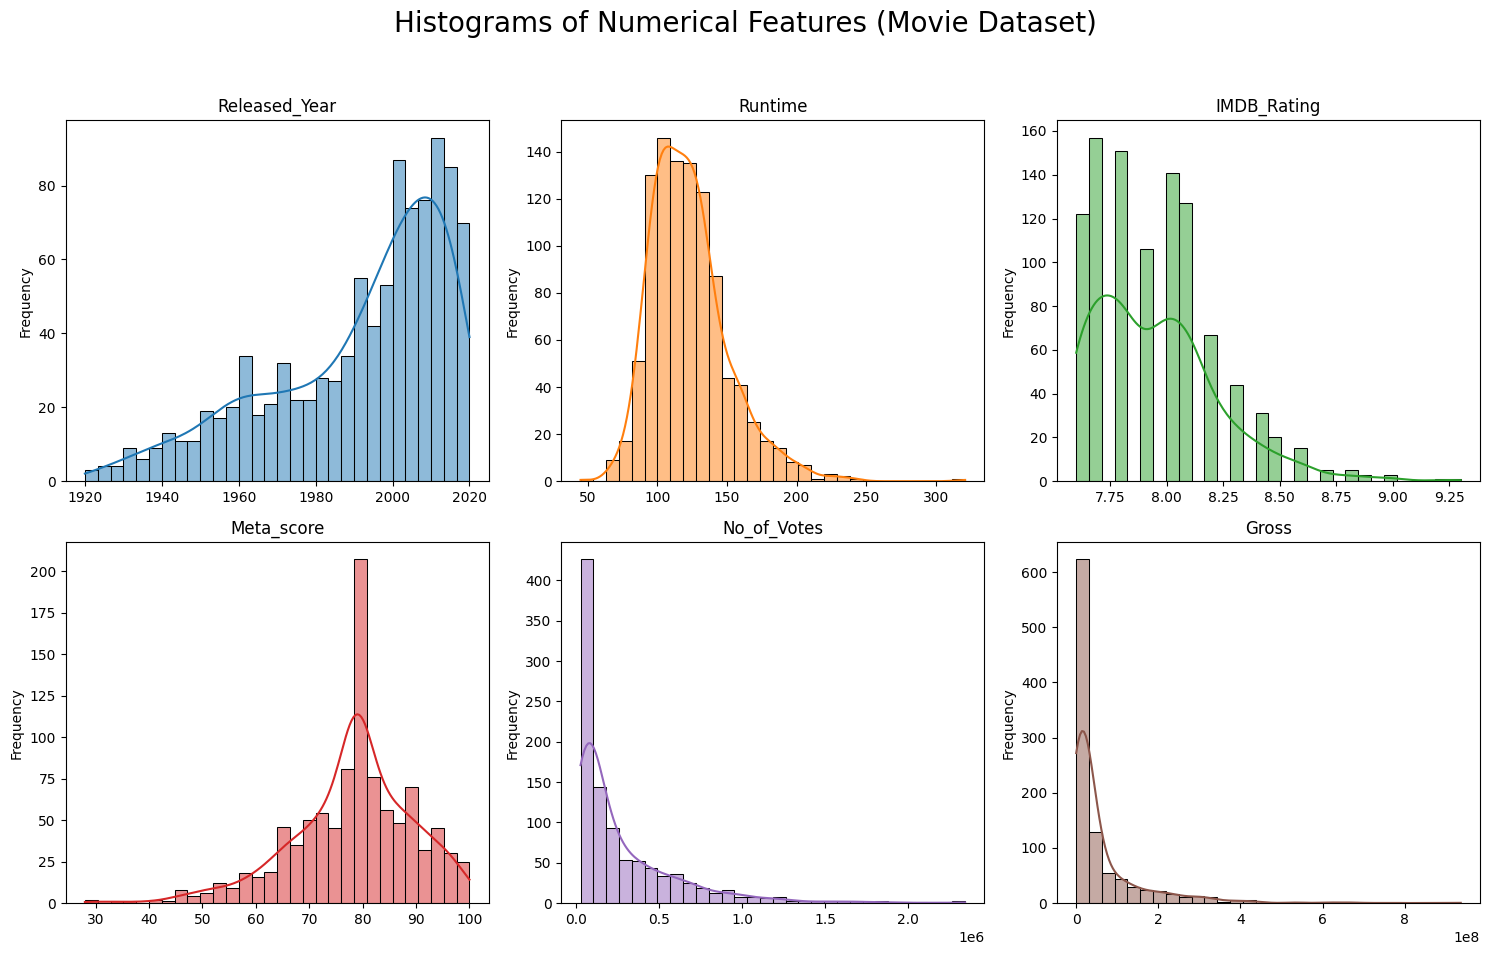

In [9]:
import math

# Histogram of numerical features
num_cols = movie_cleaned.select_dtypes(include=['int64', 'float64']).columns
cust_num = movie_cleaned[num_cols]

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

plt.suptitle(
    'Histograms of Numerical Features (Movie Dataset)',
    fontsize=20,
    fontfamily='sans-serif'
)

#Loop throughh numerical columns
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.histplot(
        data=cust_num,
        x=col,
        kde=True,
        bins=30,
        color=sns.color_palette('tab10')[i % 10]
    )

    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


The distribution analysis shows that IMDB ratings are slightly left-skewed, indicating most movies have relatively high ratings. Runtime and Meta_score are approximately normally distributed, suggesting stable central tendencies. In contrast, No_of_Votes and Gross are highly right-skewed, highlighting the presence of a few extremely popular and high-revenue movies. This justifies the use of log transformation to normalize these features for modeling.

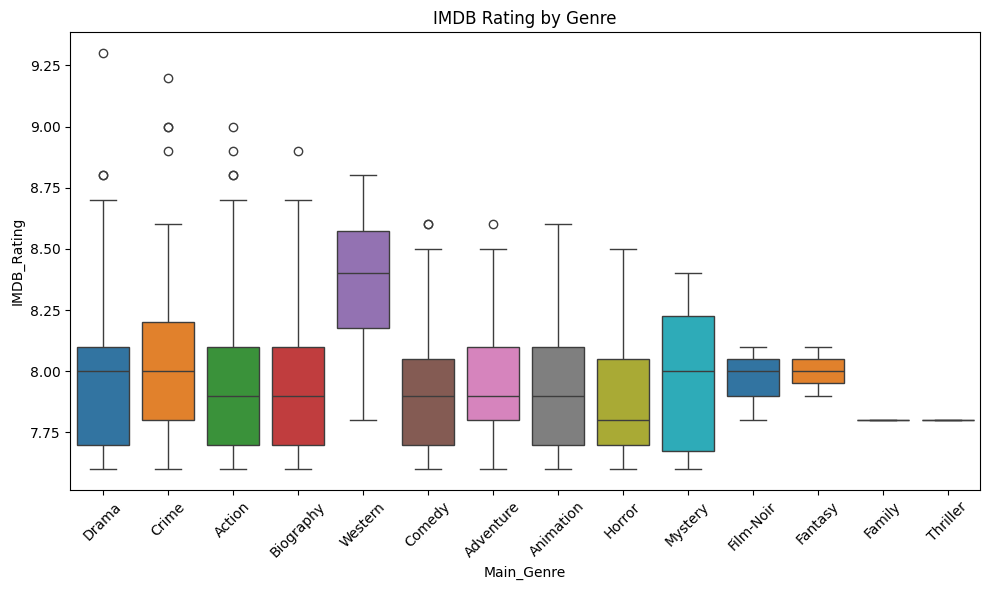

In [10]:
movie_cleaned['Main_Genre'] = movie_cleaned['Genre'].apply(lambda x: x.split(',')[0])

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=movie_cleaned,
    x='Main_Genre',
    y='IMDB_Rating',
    hue='Main_Genre',
    palette='tab10',
    legend=False
)

plt.xticks(rotation=45)
plt.title('IMDB Rating by Genre') 
plt.tight_layout() 
plt.show()

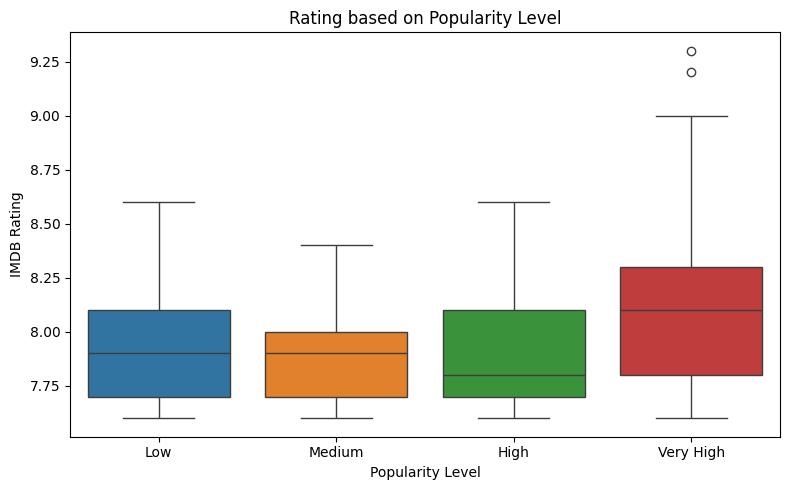

In [11]:
# Popularaty vs Rating (Binning)
movie_cleaned['Votes_Category'] = pd.qcut(
    movie_cleaned['No_of_Votes'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

plt.figure(figsize=(8,5))
sns.boxplot(
    data=movie_cleaned,
    x='Votes_Category',
    y='IMDB_Rating',
    hue='Votes_Category',
    palette='tab10',
    legend=False
)

plt.title('Rating based on Popularity Level')
plt.xlabel('Popularity Level')
plt.ylabel('IMDB Rating')
plt.tight_layout()
plt.show()


The boxplot indicates that movies with very high popularity tend to have higher median IMDB ratings, suggesting a positive relationship between popularity and audience evaluation. While lower and medium popularity levels show relatively similar distributions, the “Very High” group stands out with both higher ratings and greater variability, indicating that highly popular films are more likely to achieve top ratings but can also vary in quality.

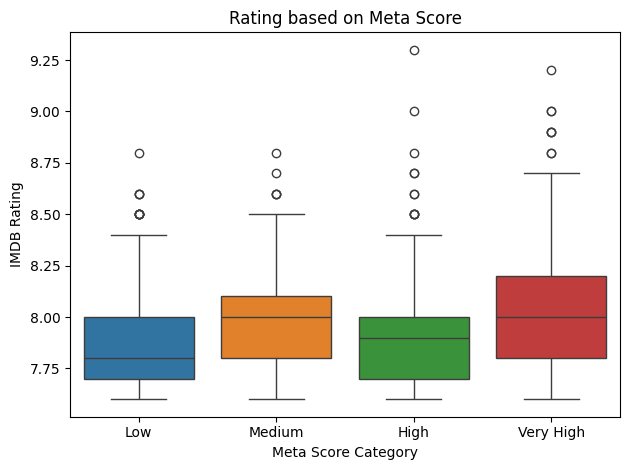

In [12]:
# Meta Score vs Rating
movie_cleaned['Meta_Category'] = pd.qcut(
    movie_cleaned['Meta_score'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

sns.boxplot(
    data=movie_cleaned,
    x='Meta_Category',
    y='IMDB_Rating',
    hue='Meta_Category',
    palette='tab10',
    legend=False
)

plt.title('Rating based on Meta Score')
plt.xlabel('Meta Score Category')
plt.ylabel('IMDB Rating')
plt.tight_layout()
plt.show()

The boxplot shows a positive trend between Meta Score and IMDB Rating, where movies with higher meta scores tend to have slightly higher median ratings. However, the overlap across categories indicates that while critic scores influence audience ratings, the relationship is moderate rather than strong, suggesting other factors also play a significant role.

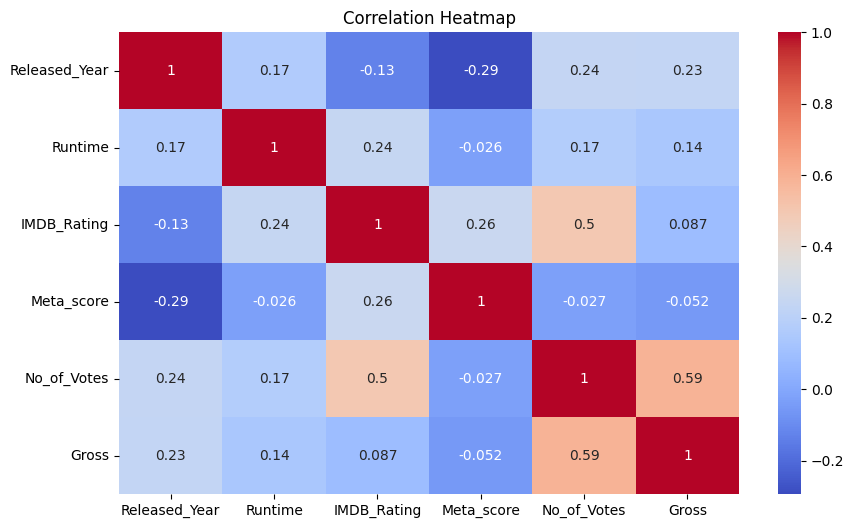

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(movie_cleaned.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation analysis shows that No_of_Votes has the strongest relationship with IMDB_Rating (0.50), indicating that more popular movies tend to receive higher ratings. Meta_score and Runtime have only weak to moderate correlations, suggesting limited direct influence. Additionally, Gross is strongly correlated with No_of_Votes (0.59), meaning highly voted movies also tend to generate higher revenue. Overall, popularity appears to be a more influential factor than other numerical features in predicting movie ratings.

## Anova

In [14]:
from scipy.stats import f_oneway

# Director Group
top_directors = movie_cleaned['Director'].value_counts().head(10).index
movie_cleaned['Director_group'] = movie_cleaned['Director'].apply(
    lambda x: x if x in top_directors else 'Other'
)

cat_cols = ['Main_Genre', 'Certificate', 'Director_group']

movie_cleaned.drop('Director', axis=1, inplace=True)

results = []

for col in cat_cols:
    groups = [
        group['IMDB_Rating'].values
        for name, group in movie_cleaned.groupby(col)
        if len(group) > 1
    ]

    if len(groups) > 1:
        f_stat, p_value = f_oneway(*groups)

        results.append({
            'Feature': col,
            'F-Statistic': f_stat,
            'P-Value': p_value,
            'Significant (<0.05)': 'Yes' if p_value < 0.05 else 'No'
        })

# Display ANOVA results
anova_df = pd.DataFrame(results)
anova_df = anova_df.sort_values(by='P-Value')
print(anova_df)


          Feature  F-Statistic       P-Value Significant (<0.05)
2  Director_group     7.747153  5.011851e-12                 Yes
1     Certificate     3.554610  6.396658e-05                 Yes
0      Main_Genre     1.801445  4.362671e-02                 Yes


All tested features (Director_group, Certificate, and Main_Genre) have a statistically significant effect on movie ratings (p < 0.05), with Director_group showing the strongest influence.

In [15]:
print(movie_cleaned.columns)

Index(['Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating',
       'Overview', 'Meta_score', 'No_of_Votes', 'Gross', 'Main_Genre',
       'Votes_Category', 'Meta_Category', 'Director_group'],
      dtype='object')


## Feature Engineering

In [16]:
# Main Genre 
movie_cleaned['Main_Genre'] = movie_cleaned['Genre'].apply(lambda x: x.split(',')[0])
movie_cleaned.drop('Genre', axis=1, inplace=True)


movie_cleaned['log_votes'] = np.log1p(movie_cleaned['No_of_Votes'])
movie_cleaned['log_gross'] = np.log1p(movie_cleaned['Gross'])
movie_cleaned.drop(['No_of_Votes','Gross'], axis=1, inplace=True)


In [17]:
df_movie = movie_cleaned.copy()

df_movie.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Released_Year   999 non-null    float64 
 1   Certificate     999 non-null    object  
 2   Runtime         999 non-null    int64   
 3   IMDB_Rating     999 non-null    float64 
 4   Overview        999 non-null    object  
 5   Meta_score      999 non-null    float64 
 6   Main_Genre      999 non-null    object  
 7   Votes_Category  999 non-null    category
 8   Meta_Category   999 non-null    category
 9   Director_group  999 non-null    object  
 10  log_votes       999 non-null    float64 
 11  log_gross       999 non-null    float64 
dtypes: category(2), float64(5), int64(1), object(4)
memory usage: 88.2+ KB


## Split Feature & Target

In [18]:
# Separate features and target variable 
X = df_movie.drop(['IMDB_Rating', 'Overview'], axis=1, errors='ignore')
y = df_movie['IMDB_Rating']

In [19]:
from sklearn.model_selection import train_test_split

# Define preprocessing steps
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Preprocessing

In [20]:

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ]
)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
}

results = []

def evaluate_model(models, preprocessor, X_train, X_test, y_train, y_test):
    best_model = None
    best_r2 = -np.inf 

    for name, model in models.items():
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        #Train the model
        pipeline.fit(X_train, y_train)

        # Predict on test set
        y_pred = pipeline.predict(X_test)

        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        # Track best model
        if r2 > best_r2:
            best_r2 = r2
            best_model = pipeline
            best_model_name = name
    
    return pd.DataFrame(results), best_model, best_model_name

results_df, best_model, best_model_name = evaluate_model(
    models, preprocessor, X_train, X_test, y_train, y_test
) 

results_df = results_df.sort_values(by='R2', ascending=False)
print("Model Comparison:")
display(results_df.style.format({
    'MAE': '{:.3f}',
    'RMSE': '{:.3f}',
    'R2': '{:.3f}'
}))

print(f"🏆 Best Model: {best_model_name}")

Model Comparison:


,Model,MAE,RMSE,R2
1,Random Forest,0.141,0.032,0.510
2,XGBoost,0.146,0.035,0.460
0,Linear Regression,0.178,0.049,0.246


🏆 Best Model: Random Forest


Random Forest achieved the best performance among the evaluated models, with the lowest error and highest R², indicating its effectiveness in capturing non-linear relationships in the dataset. This suggests it is the most suitable model for predicting movie ratings given the data characteristics.

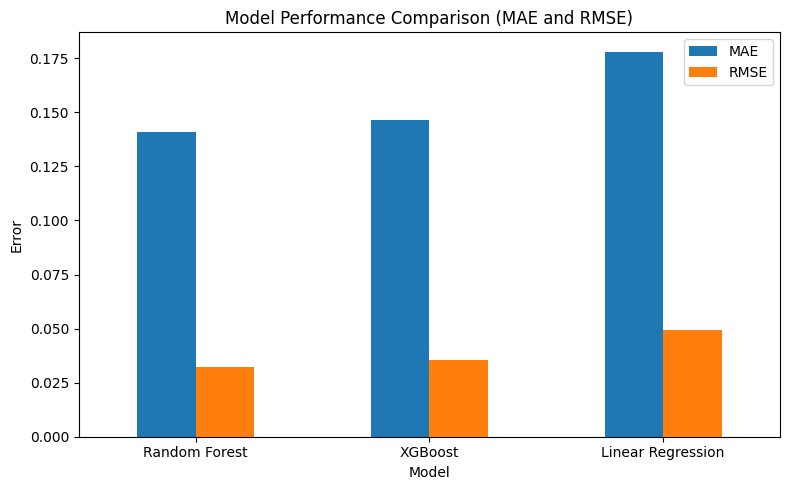

In [22]:
results_df = results_df.sort_values(by='R2', ascending=False)
results_df.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(8,5))


plt.title('Model Performance Comparison (MAE and RMSE)')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

param_dist = {
    'model__n_estimators': [100, 150],
    'model__max_depth': [5, 8, 10],  
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf': [2, 4, 6],
    'model__max_features': ['sqrt']
}

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_dist,
    n_iter = 25,
    scoring = 'r2',
    cv = 5,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)

print("Best Parameter:")
print(random_search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameter:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10}


In [24]:
# Best model
best_model = random_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print("R2 Train :", round(r2_score(y_train, y_train_pred), 4))
print("R2 Test :", round(r2_score(y_test, y_test_pred), 4))

print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))

R2 Train : 0.6055
R2 Test : 0.3916
MAE : 0.16237968187667295
RMSE : 0.1995933017818877


In [25]:
from sklearn.metrics import r2_score

# Prediction train and test
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# R2 Score
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("R2 Train :", round(r2_train, 4))
print("R2 Test :", round(r2_test, 4))

# GAP
gap =  abs(r2_train - r2_test)
print("\nGAP (Overfiting Check):", round(gap, 4))


R2 Train : 0.6055
R2 Test : 0.3916

GAP (Overfiting Check): 0.214


In [26]:
model = best_model.named_steps['model']
preprocessor = best_model.named_steps['preprocessor']

num_features = num_cols
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_name = list(num_features) + list(cat_features)

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_name,
    'Importance': importances 
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
3,log_votes,0.370320
2,Meta_score,0.134489
1,Runtime,0.116933
0,Released_Year,0.098380
4,log_gross,0.082805
41,Director_group_Other,0.032697
26,Main_Genre_Crime,0.015240
6,Certificate_A,0.014144
38,Director_group_Christopher Nolan,0.012489
21,Main_Genre_Action,0.011502


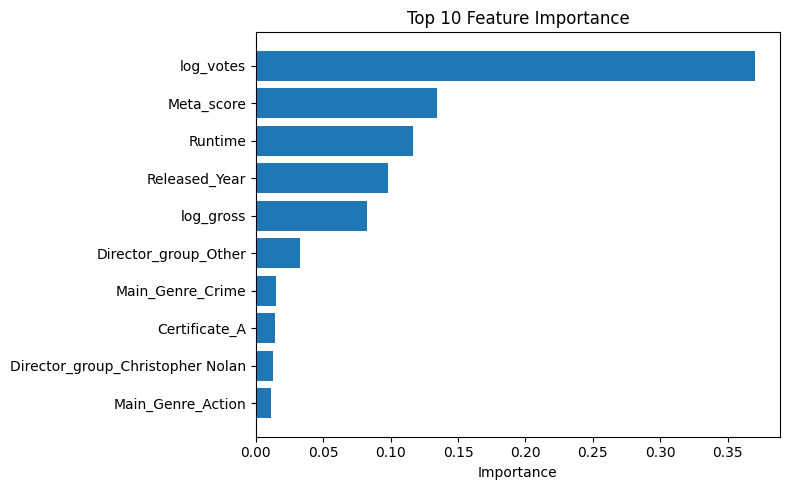

In [27]:
top_features = feat_imp.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Business Insight

The model indicates that movie popularity (log_votes) is the most influential factor in determining ratings, suggesting that films with higher audience engagement tend to receive better evaluations. Critical reception (Meta_score) and production attributes like runtime and release year also play significant roles, highlighting the importance of both quality and timing. Additionally, director reputation and genre contribute to performance, implying that well-known directors and certain genres (e.g., Crime, Action) can positively influence audience perception. Overall, both popularity and content quality are key drivers of movie success.